# Análise de Teoria dos Grafos
---

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from collections import Counter

# ── Carrega o grafo ──────────────────────────────────────────────────────────
df = pd.read_csv('grafo_sem_tempo.csv')

G = nx.from_pandas_edgelist(
    df,
    source='source',
    target='target',
    edge_attr='weight',
    create_using=nx.DiGraph()
)

print(f"Grafo carregado: {G.number_of_nodes():,} nós  |  {G.number_of_edges():,} arestas")

Grafo carregado: 3,783 nós  |  24,186 arestas


/home/estrela/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
## 1 · Número de Vértices e Arestas
####################################################
n_vertices = G.number_of_nodes()
n_arestas  = G.number_of_edges()

print(f"Número de vértices : {n_vertices:,}")
print(f"Número de arestas  : {n_arestas:,}")

Número de vértices : 3,783
Número de arestas  : 24,186


In [3]:
## 2 · Grau Mínimo, Máximo e Médio
####################################################

graus = dict(G.degree())          # grau total (in + out)
grau_vals = list(graus.values())

grau_min  = min(grau_vals)
grau_max  = max(grau_vals)
grau_med  = np.mean(grau_vals)

node_min = [n for n, d in graus.items() if d == grau_min]
node_max = [n for n, d in graus.items() if d == grau_max]

print(f"Grau mínimo : {grau_min}  — ex: nós {node_min[:5]}")
print(f"Grau máximo : {grau_max}  — ex: nós {node_max[:5]}")
print(f"Grau médio  : {grau_med:.4f}")

Grau mínimo : 1  — ex: nós [7188, 1028, 2367, 2296, 3421]
Grau máximo : 888  — ex: nós [1]
Grau médio  : 12.7867


## 3 · Distribuição de Graus

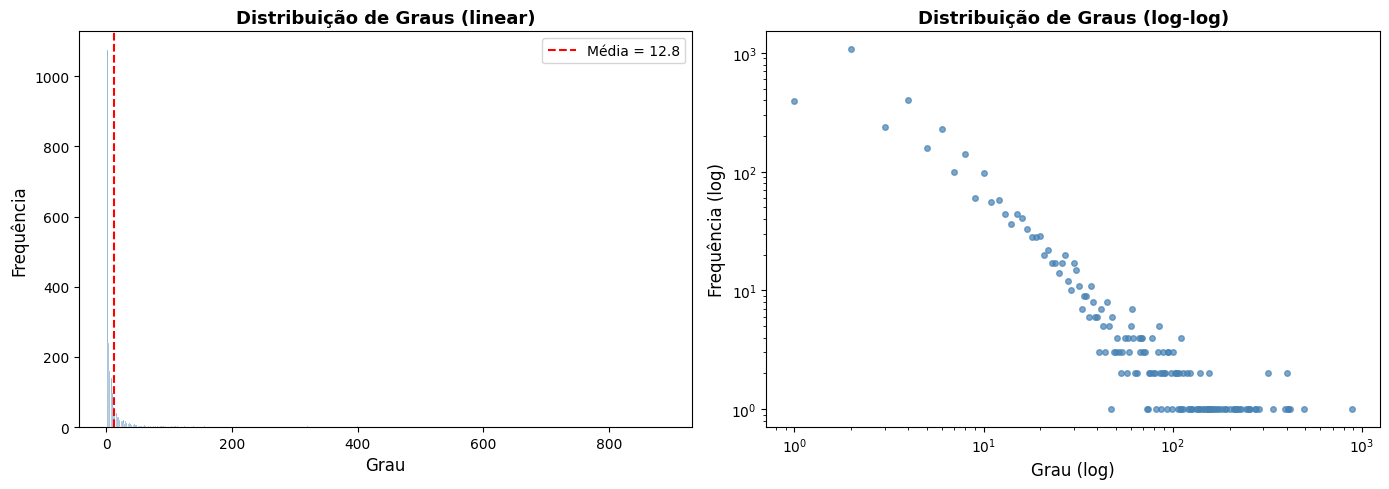

Gráfico salvo em distribuicao_graus.png


In [4]:
## 3 · Distribuição de Graus
####################################################
contagem = Counter(grau_vals)
graus_sorted = sorted(contagem.keys())
freq_sorted  = [contagem[g] for g in graus_sorted]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição linear
axes[0].bar(graus_sorted, freq_sorted, color='steelblue', alpha=0.85, edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('Grau', fontsize=12)
axes[0].set_ylabel('Frequência', fontsize=12)
axes[0].set_title('Distribuição de Graus (linear)', fontsize=13, fontweight='bold')
axes[0].axvline(grau_med, color='red', linestyle='--', linewidth=1.5, label=f'Média = {grau_med:.1f}')
axes[0].legend()

# Distribuição log-log
axes[1].loglog(graus_sorted, freq_sorted, 'o', color='steelblue', alpha=0.7, markersize=4)
axes[1].set_xlabel('Grau (log)', fontsize=12)
axes[1].set_ylabel('Frequência (log)', fontsize=12)
axes[1].set_title('Distribuição de Graus (log-log)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('distribuicao_graus.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo em distribuicao_graus.png")

In [5]:
## 4 · Densidade
####################################################
# Para dígrafo: D = |E| / (|V| * (|V| - 1))
densidade = nx.density(G)

print(f"Densidade : {densidade:.6f}")
print(f"  → O grafo possui {densidade*100:.4f}% das arestas possíveis.")
if densidade < 0.01:
    print("  → Grafo ESPARSO (densidade < 1%)")
else:
    print("  → Grafo DENSO (densidade ≥ 1%)")

Densidade : 0.001690
  → O grafo possui 0.1690% das arestas possíveis.
  → Grafo ESPARSO (densidade < 1%)


In [6]:
## 5 · Componentes Conexas
#Para dígrafos analisamos componentes **fracamente** (WCC) e **fortemente** (SCC) conexas.
###################################################
# Componentes Fracamente Conexas (WCC)
wccs = list(nx.weakly_connected_components(G))
wcc_sizes = sorted([len(c) for c in wccs], reverse=True)

# Componentes Fortemente Conexas (SCC)
sccs = list(nx.strongly_connected_components(G))
scc_sizes = sorted([len(c) for c in sccs], reverse=True)

print("── Componentes Fracamente Conexas (WCC) ──")
print(f"  Número de WCCs  : {len(wccs)}")
print(f"  Tamanhos (top 10): {wcc_sizes[:10]}")

print()
print("── Componentes Fortemente Conexas (SCC) ──")
print(f"  Número de SCCs  : {len(sccs)}")
print(f"  Tamanhos (top 10): {scc_sizes[:10]}")

── Componentes Fracamente Conexas (WCC) ──
  Número de WCCs  : 5
  Tamanhos (top 10): [3775, 2, 2, 2, 2]

── Componentes Fortemente Conexas (SCC) ──
  Número de SCCs  : 540
  Tamanhos (top 10): [3235, 3, 3, 2, 2, 2, 2, 2, 1, 1]


In [7]:
## 6 · Diâmetro e Raio
####################################################

scc_nodes = max(nx.strongly_connected_components(G), key=len)
SCC = G.subgraph(scc_nodes).copy()

print(f"Maior SCC: {SCC.number_of_nodes():,} nós ({100*SCC.number_of_nodes()/G.number_of_nodes():.1f}% do grafo total)")
print("Calculando excentricidades (pode levar alguns segundos)...")

ecc      = nx.eccentricity(SCC)
diametro = nx.diameter(SCC, e=ecc)
raio     = nx.radius(SCC, e=ecc)
centro   = nx.center(SCC, e=ecc)
periferia = nx.periphery(SCC, e=ecc)

print(f"\nDiâmetro  : {diametro}")
print(f"Raio      : {raio}")
print(f"Centro    : {len(centro)} nós  — ex: {sorted(centro)[:8]}")
print(f"Periferia : {len(periferia)} nós — ex: {sorted(periferia)[:8]}")

Maior SCC: 3,235 nós (85.5% do grafo total)
Calculando excentricidades (pode levar alguns segundos)...

Diâmetro  : 10
Raio      : 5
Centro    : 41 nós  — ex: [1, 2, 4, 6, 8, 10, 16, 17]
Periferia : 1 nós — ex: [1329]


In [8]:
## 7 · Comprimento Médio dos Caminhos
####################################################
# Calculado na maior SCC
print("Calculando comprimento médio dos caminhos na maior SCC...")
avg_path = nx.average_shortest_path_length(SCC)

print(f"Comprimento médio dos caminhos : {avg_path:.4f}")
print(f"  → Em média, dois nós quaisquer estão a {avg_path:.2f} saltos de distância.")

Calculando comprimento médio dos caminhos na maior SCC...
Comprimento médio dos caminhos : 3.6485
  → Em média, dois nós quaisquer estão a 3.65 saltos de distância.


In [9]:
## 8 · Coeficiente de Clusterização Médio
####################################################
# nx.average_clustering suporta dígrafos diretamente
print("Calculando coeficiente de clusterização...")
clustering_medio = nx.average_clustering(G)
clustering_por_no = nx.clustering(G)

print(f"Coeficiente de clusterização médio : {clustering_medio:.4f}")

top5_cluster = sorted(clustering_por_no.items(), key=lambda x: x[1], reverse=True)[:5]
print(f"\nTop-5 nós com maior clusterização:")
for node, cc in top5_cluster:
    print(f"  Nó {node:>6}  →  {cc:.4f}")

Calculando coeficiente de clusterização...
Coeficiente de clusterização médio : 0.1583

Top-5 nós com maior clusterização:
  Nó   1496  →  1.0000
  Nó   1445  →  1.0000
  Nó   1881  →  1.0000
  Nó   2167  →  1.0000
  Nó    736  →  1.0000


In [10]:
## 9 · Número de Triângulos
####################################################
# nx.triangles trabalha no grafo não-dirigido subjacente
G_und = G.to_undirected()
triangulos_por_no = nx.triangles(G_und)
total_triangulos = sum(triangulos_por_no.values()) // 3  # cada triângulo contado 3x

print(f"Número de triângulos : {total_triangulos:,}")

top5_tri = sorted(triangulos_por_no.items(), key=lambda x: x[1], reverse=True)[:5]
print(f"\nTop-5 nós participantes em mais triângulos:")
for node, t in top5_tri:
    print(f"  Nó {node:>6}  →  {t:,} triângulos")

Número de triângulos : 22,153

Top-5 nós participantes em mais triângulos:
  Nó     11  →  1,815 triângulos
  Nó      2  →  1,628 triângulos
  Nó    177  →  1,414 triângulos
  Nó      3  →  1,336 triângulos
  Nó      7  →  1,181 triângulos


Visualizando subgrafo com 300 nós e 7085 arestas...


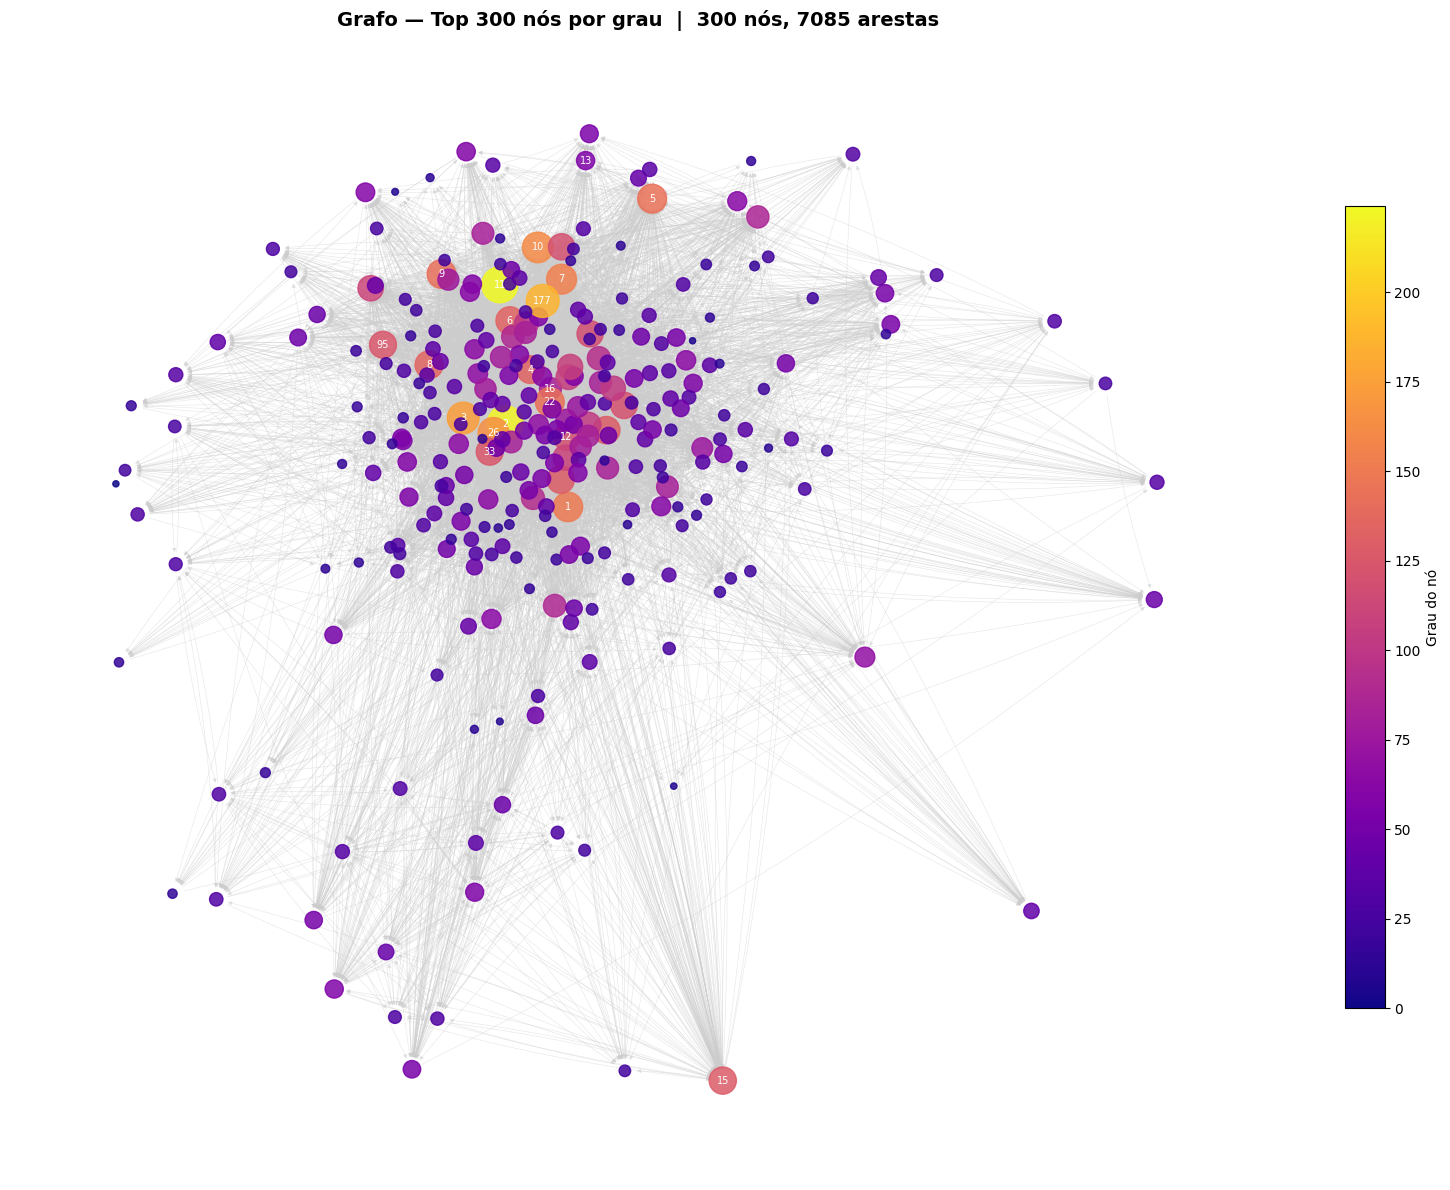

Visualização salva em visualizacao_grafo.png


In [11]:
## 10 · Visualização do Grafo (versão reduzida)
####################################################
# Usa a maior WCC e amostra os nós de maior grau para legibilidade
wcc_nodes = max(nx.weakly_connected_components(G), key=len)
G_wcc = G.subgraph(wcc_nodes).copy()

TOP_N = 300  # ajuste conforme necessário
top_nodes = sorted(G_wcc.degree(), key=lambda x: x[1], reverse=True)[:TOP_N]
top_ids   = [n for n, _ in top_nodes]
G_vis = G_wcc.subgraph(top_ids).copy()

print(f"Visualizando subgrafo com {G_vis.number_of_nodes()} nós e {G_vis.number_of_edges()} arestas...")

degrees   = dict(G_vis.degree())
node_size = [max(20, degrees[n] * 3) for n in G_vis.nodes()]
node_color = [degrees[n] for n in G_vis.nodes()]

pos = nx.spring_layout(G_vis, seed=42, k=0.4)

fig, ax = plt.subplots(figsize=(16, 12))
nx.draw_networkx_nodes(
    G_vis, pos, ax=ax,
    node_size=node_size,
    node_color=node_color,
    cmap=cm.plasma,
    alpha=0.85
)
nx.draw_networkx_edges(
    G_vis, pos, ax=ax,
    edge_color='#cccccc',
    width=0.4,
    alpha=0.5,
    arrows=True,
    arrowsize=6,
    connectionstyle='arc3,rad=0.05'
)

# Rótulos apenas nos 20 hubs principais
hub_ids = [n for n, _ in top_nodes[:20]]
labels  = {n: str(n) for n in hub_ids if n in G_vis.nodes()}
nx.draw_networkx_labels(G_vis, pos, labels=labels, font_size=7, font_color='white', ax=ax)

sm = plt.cm.ScalarMappable(cmap=cm.plasma, norm=plt.Normalize(vmin=min(node_color), vmax=max(node_color)))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Grau do nó', shrink=0.7)

ax.set_title(
    f'Grafo — Top {TOP_N} nós por grau  |  '
    f'{G_vis.number_of_nodes()} nós, {G_vis.number_of_edges()} arestas',
    fontsize=14, fontweight='bold'
)
ax.axis('off')
plt.tight_layout()
plt.savefig('visualizacao_grafo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualização salva em visualizacao_grafo.png")

## Resumo Geral

In [12]:
print("═" * 50)
print("RESUMO — ANÁLISE DO GRAFO")
print("═" * 50)
print(f"  Vértices                    : {n_vertices:,}")
print(f"  Arestas                     : {n_arestas:,}")
print(f"  Grau mínimo                 : {grau_min}")
print(f"  Grau máximo                 : {grau_max}")
print(f"  Grau médio                  : {grau_med:.4f}")
print(f"  Densidade                   : {densidade:.6f}")
print(f"  Componentes WCC             : {len(wccs)}")
print(f"  Componentes SCC             : {len(sccs)}")
print(f"  Tamanhos WCC (top 5)        : {wcc_sizes[:5]}")
print(f"  Tamanhos SCC (top 5)        : {scc_sizes[:5]}")
print(f"  Diâmetro (maior SCC)        : {diametro}")
print(f"  Raio (maior SCC)            : {raio}")
print(f"  Comprimento médio caminhos  : {avg_path:.4f}")
print(f"  Clusterização médio         : {clustering_medio:.4f}")
print(f"  Triângulos                  : {total_triangulos:,}")
print("═" * 50)

══════════════════════════════════════════════════
RESUMO — ANÁLISE DO GRAFO
══════════════════════════════════════════════════
  Vértices                    : 3,783
  Arestas                     : 24,186
  Grau mínimo                 : 1
  Grau máximo                 : 888
  Grau médio                  : 12.7867
  Densidade                   : 0.001690
  Componentes WCC             : 5
  Componentes SCC             : 540
  Tamanhos WCC (top 5)        : [3775, 2, 2, 2, 2]
  Tamanhos SCC (top 5)        : [3235, 3, 3, 2, 2]
  Diâmetro (maior SCC)        : 10
  Raio (maior SCC)            : 5
  Comprimento médio caminhos  : 3.6485
  Clusterização médio         : 0.1583
  Triângulos                  : 22,153
══════════════════════════════════════════════════


In [13]:
# Resumo final consolidado

print('RESSALVAS:')
print('  • Diâmetro/Raio/Comprimento médio: restritos à maior SCC (grafo não é')
print('    totalmente fortemente conexo; pares sem caminho dariam distância ∞).')
print('  • Distâncias usam hop-count (pesos negativos inviabilizam Dijkstra).')
print('  • Triângulos calculados no grafo não-dirigido (limitação do NetworkX).')


RESSALVAS:
  • Diâmetro/Raio/Comprimento médio: restritos à maior SCC (grafo não é
    totalmente fortemente conexo; pares sem caminho dariam distância ∞).
  • Distâncias usam hop-count (pesos negativos inviabilizam Dijkstra).
  • Triângulos calculados no grafo não-dirigido (limitação do NetworkX).
